In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# READ TELESCOPIC CONFIGURATION
df_hole_to_casing = pd.read_csv(r"database\holesize_to_casing.csv")
df_casing_to_hole = pd.read_csv(r"database\casing_to_holesize.csv")

# READ AND NORMALIZE VAM DATA FRAME
from src.database_processor.vam_data_process import get_VAM_OCTG_data
df_vam_data = get_VAM_OCTG_data(r"database\VAM_connections_data.xlsx", basic=True)
print(f"Total unique pipe options: {len(df_vam_data)}")



Total unique pipe options: 764


In [2]:
from src.collapse.api5c3_design import API5C3DesignMethod
from src.collapse.klever_tamano import KleverTamanoMethod
from src.entities.tubular import TubularData
from src.entities.klever_tamano_parameters import DEFAULT_KT_PARAMS
from src.entities.steel_grade import SteelGrade

_api = API5C3DesignMethod()
_kt  = KleverTamanoMethod()


def _build(row):
    grade = SteelGrade(name=str(row['Yield stress (ksi)']),
                       yield_strength=row['Yield stress (ksi)'] * 1000)  # ksi -> psi
    tubular = TubularData(od=row['Size OD (in)'], wt=row['Wall Thickness (in)'], grade=grade)
    return tubular, grade

def get_collapse_regime(row):
    tubular, grade = _build(row)
    return _api.get_regime(tubular, grade)

df_vam_data['Collapse Regime'] = df_vam_data.apply(get_collapse_regime, axis=1)
print(df_vam_data['Collapse Regime'].value_counts())


Collapse Regime
plastic       316
yield         247
transition    137
elastic        64
Name: count, dtype: int64


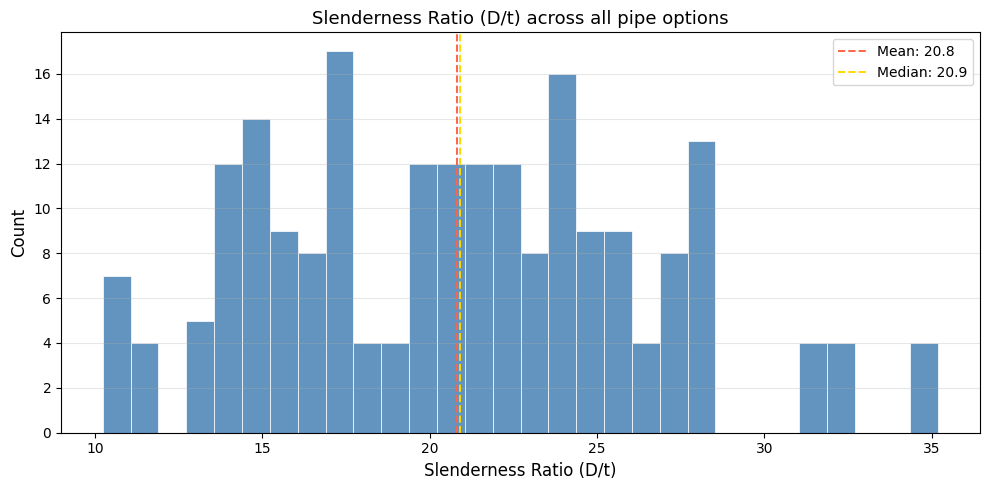

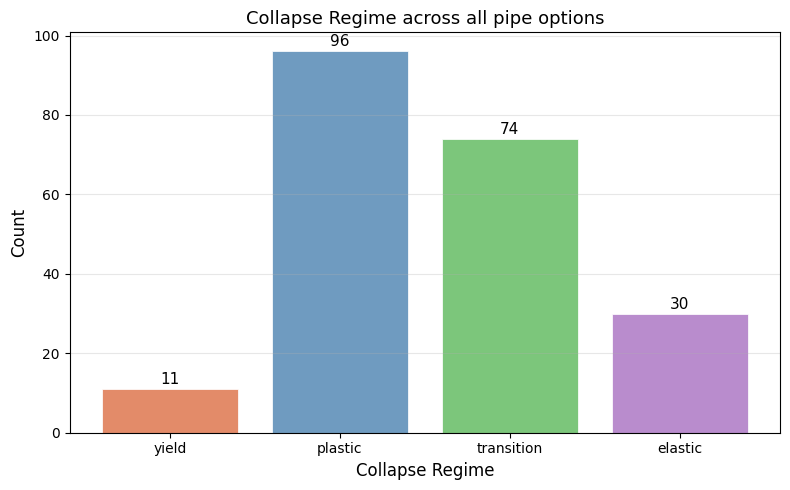

9.625 [np.float64(16.176), np.float64(21.344), np.float64(27.344)]
9.875 [np.float64(13.621), np.float64(14.617), np.float64(15.8)]
10.75 [np.float64(10.238), np.float64(16.984), np.float64(26.875)]
11.75 [np.float64(20.189), np.float64(23.308), np.float64(27.011)]
11.875 [np.float64(20.404), np.float64(20.997), np.float64(21.591)]
13.375 [np.float64(21.998), np.float64(27.081), np.float64(35.197)]
14.0 [np.float64(17.073), np.float64(20.051), np.float64(24.911)]
16.0 [np.float64(24.39), np.float64(27.454), np.float64(32.323)]


HTML(value='\n        <div style="max-height: 420px; overflow-y: auto; overflow-x: auto; border: 1px solid #cc…

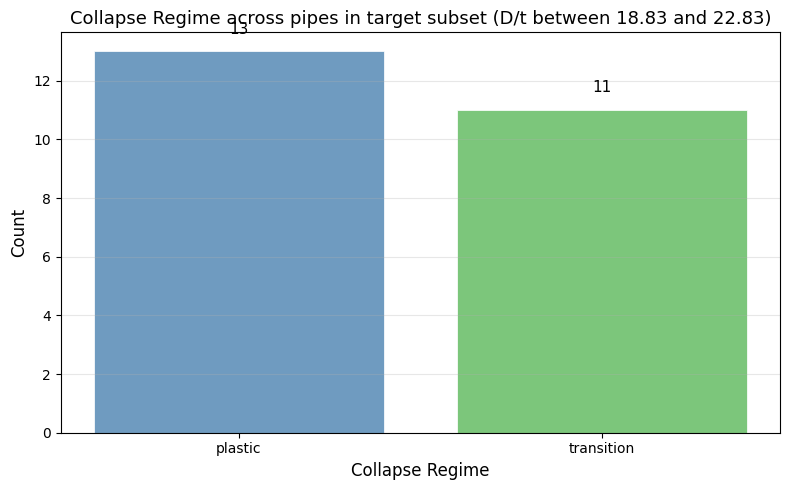

In [5]:
from src.visualization.vis_charts import plot_histogram, plot_bar_chart, REGIME_ORDER, REGIME_COLORS
from IPython.display import display
import ipywidgets as widgets

hole_to_casing_filtered = df_hole_to_casing[
    df_hole_to_casing['Hole Size (in)'].between(12.25, 20, inclusive='both')
].sort_values(['Hole Size (in)', 'Casing OD (in)'], ascending=[False, False])

casing_od_options = hole_to_casing_filtered['Casing OD (in)'].drop_duplicates().sort_values(ascending=False).reset_index(drop=True)

# casing_od_options = (14.0, 13.375, 10.75, 11.75, 11.875, 9.625)
unique_pipes = df_vam_data[df_vam_data['Size OD (in)'].isin(casing_od_options)]

plot_histogram(unique_pipes['Slenderness Ratio'], title='Slenderness Ratio (D/t) across all pipe options', xlabel='Slenderness Ratio (D/t)')
plot_bar_chart(unique_pipes['Collapse Regime'], title='Collapse Regime across all pipe options',
               xlabel='Collapse Regime', order=REGIME_ORDER, colors=REGIME_COLORS)

od_mean = unique_pipes['Slenderness Ratio'].mean()
od_dev = 2.0

target_subset = unique_pipes.iloc[0:0].copy()
for od in np.unique(unique_pipes['Size OD (in)']):
    slen = unique_pipes[unique_pipes['Size OD (in)'] == od]['Slenderness Ratio']
    print(od, [np.round(x,3) for x in [slen.min(), slen.mean(), slen.max()]])
    od_subset = unique_pipes[unique_pipes['Size OD (in)'] == od]
    closest_idx = (od_subset['Slenderness Ratio'] - od_mean).abs().idxmin()
    if abs(od_subset.loc[closest_idx, 'Slenderness Ratio'] - od_mean) < od_dev:
        curr_subset = od_subset[od_subset['Slenderness Ratio'] == od_subset.loc[closest_idx]['Slenderness Ratio']]
        target_subset = pd.concat([target_subset, curr_subset], ignore_index=True)
    # print(od_subset[od_subset["Slenderness Ratio"] == od_subset.loc[closest_idx]['Slenderness Ratio']])

try:
    target_subset = target_subset.copy().sort_values(
        ['Size OD (in)', 'Yield stress (ksi)', 'Wall Thickness (in)'],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    numeric_cols = target_subset.select_dtypes(include=[np.number]).columns
    target_subset[numeric_cols] = target_subset[numeric_cols].round(3)
    table_widget = widgets.HTML(
        value=f"""
        <div style="max-height: 420px; overflow-y: auto; overflow-x: auto; border: 1px solid #ccc; padding: 4px;">
            <style>
                table.dataframe {{
                    border-collapse: collapse;
                    width: 100%;
                    font-size: 12px;
                }}
                table.dataframe thead th {{
                    position: sticky;
                    top: 0;
                    background: white;
                    z-index: 1;
                }}
            </style>
            {target_subset.to_html(index=False)}
        </div>
        """
    )
    display(table_widget)

except ImportError:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
        display(target_subset)
plot_bar_chart(target_subset['Collapse Regime'], title='Collapse Regime across pipes in target subset (D/t between {:.2f} and {:.2f})'.format(od_mean - od_dev, od_mean + od_dev),
               xlabel='Collapse Regime', order=REGIME_ORDER, colors=REGIME_COLORS)

    # closest_pipe = od_subset.loc[closest_idx]
    # fig, ax = plt.subplots(figsize=(7, 4))
    # ax.scatter(
    #     od_subset['Wall Thickness (in)'],
    #     od_subset['Slenderness Ratio'],
    #     alpha=0.6,
    #     s=40,
    #     label='Pipes'
    # )
    # ax.scatter(
    #     closest_pipe['Wall Thickness (in)'],
    #     closest_pipe['Slenderness Ratio'],
    #     color='crimson',
    #     s=90,
    #     zorder=3,
    #     label=f"Closest to 20: {closest_pipe['Slenderness Ratio']:.2f}"
    # )
    # ax.axhline(20, color='gray', linestyle='--', linewidth=1)

    # ax.set_title(f'OD {od}" — Pipe closest to Slenderness 20')
    # ax.set_xlabel('Wall Thickness (in)')
    # ax.set_ylabel('Slenderness Ratio (D/t)')
    # ax.grid(alpha=0.3)
    # ax.legend()
    # plt.tight_layout()
    # plt.show()



In [ ]:
# Plot Size (OD) vs Slenderness Ratio
plt.figure(figsize=(10, 6))
plt.scatter(unique_pipes['Size (OD)'], unique_pipes['Slenderness Ratio'], alpha=0.6, s=50)
plt.xlabel('Size (OD) [inches]')
plt.ylabel('Slenderness Ratio (OD/WT)')
plt.title('Pipe Size vs Slenderness Ratio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Histogram of Slenderness Ratio (D/t) across all pipe options
slenderness = df_vam_data['Slenderness Ratio'].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(
    slenderness,
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85,
)

ax.axvline(slenderness.mean(), color='tomato', linestyle='--', linewidth=1.4,
           label=f'Mean: {slenderness.mean():.1f}')
ax.axvline(slenderness.median(), color='gold', linestyle='--', linewidth=1.4,
           label=f'Median: {slenderness.median():.1f}')

ax.set_xlabel('Slenderness Ratio (D/t)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Slenderness Ratio (D/t) — VAM OCTG Pipe Options', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
